In [1]:
from pymodulon.core import IcaData
from pymodulon.plotting import *
from os import path
import pandas as pd
import re
from Bio.KEGG import REST
from tqdm.notebook import tqdm
from pymodulon.io import *
from pymodulon.compare import *
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import variation
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100, 'display.max_rows', 100)

In [2]:
# Editing text on PDF:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [3]:
ica_data = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')

In [4]:
# filtering out single gene iMs from A matrix for analysis
A_no_sg = ica_data.A.copy()

for idx, row in A_no_sg.iterrows():
    if idx.__contains__('SG_') == True:
        A_no_sg = A_no_sg.drop(idx)

In [5]:
def cluster_activities_no_sg(
    ica_data,
    correlation_method="spearman",
    distance_threshold=None,
    show_thresholding=False,
    show_clustermap=True,
    show_best_clusters=False,
    n_best_clusters="auto",
    cluster_names=None,
    return_clustermap=False,
    # dimca options
    dimca_sample1=None,
    dimca_sample2=None,
    dimca_threshold=3,
    dimca_fdr=0.1,
    dimca_label=True,
    dimca_adjust=True,
    dimca_table=False,
    **dima_kwargs,
):
    """
    Cluster all non-SG iModulon activity profiles using hierarchical clustering and display
    the results using :func:`seaborn.clustermap`

    Parameters
    ----------
    ica_data: ~pymodulon.core.IcaData
        :class:`~pymodulon.core.IcaData` object
    correlation_method: 'pearson', 'spearman', 'kendall', 'mutual_info' or callable
        Method for computing correlations between iModulon activities. See
        :meth:`pandas.DataFrame.corr` Default is 'spearman'.
    distance_threshold: float, optional
        A distance from 0 to 1 to define flat clusters from the hierarchical
        clustering. Larger values yield fewer clusters. If None, automatic selection
        of optimal threshold will occur by maximizing the silhouette score across
        iModulons. (default: None)
    show_thresholding: bool
        Show the plot of distance thresholds vs. silhouette scores (default: False)
    show_clustermap: bool
        Show the clustermap (default: True)
    show_best_clusters: bool
        Show individual clusters below complete clustermap
    n_best_clusters: int or str
        Number of best clusters to show. If 'auto', only clusters with above-average
        silhouette scores are shown
    cluster_names: dict, optional
        A dictionary mapping cluster indices to names, usually used after clustering
        has been performed previously.
    return_clustermap: bool
        Return the axis containing the clustermap
    dimca_sample1: list or str
        List of sample IDs or name of "project:condition" of reference samples for
        Differential iModulon Cluster Analysis (DiMCA)
    dimca_sample2: list or str
        List of sample IDs or name of "project:condition" of target samples for
        DiMCA
    dimca_threshold: float
        Minimum activity difference to determine DiMCAs
    dimca_fdr: float
        False detection rate for DiMCA
    dimca_label: bool
        Label differentially activated imodulon clusters (default: True)
    dimca_adjust: bool
        Auto-adjust DiMCA cluster labels (default: True)
    dimca_table: bool
        Return DiMCA table (default: False)
    **dima_kwargs: dict, optional
        Additional keyword arguments passed to :func:`pymodulon.plotting.dima`

    Returns
    -------
    clusters: ~sklearn.cluster.AgglomerativeClustering
        :class:`sklearn.cluster.AgglomerativeClustering` of activity matrix
    cg: ~seaborn.matrix.ClusterGrid, optional
        :class:`~seaborn.matrix.ClusterGrid` containing the clusterplot
    dimca_ax: ~matplotlib.axes.Axes, optional
        :class:`~matplotlib.axes.Axes` containing the DiMCA scatterplot
    dimca_table: ~pandas.DataFrame, optional
        Table of differentially activated iModulon clusters
    """

    # compute distance matrix; distance metric defined as 1 - correlation to
    # ensure that correlated iModulons are close in distance, can be clustered

    if correlation_method == "mutual_info":
        correlation_df = 1 - A_no_sg.T.corr(method=mutual_info_distance)
        distance_matrix = 1 - correlation_df.abs() - np.eye(len(correlation_df))
        correlation_df = (correlation_df - correlation_df.min().min()) / (
            correlation_df.max().max()
        ) + np.eye(len(correlation_df))
    else:
        correlation_df = A_no_sg.T.corr(method=correlation_method)
        distance_matrix = 1 - correlation_df.abs()

    best_clusters = []
    cluster_score_dict = {}

    # define a base instance of the clustering object we will use throughout;
    # the distance threshold here is a dummy; we will replace this with either
    # the user-specified value or an automatically-selected value
    agg_cluster_base = AgglomerativeClustering(
        n_clusters=None,
        affinity="precomputed",
        compute_full_tree=True,
        linkage="complete",
        distance_threshold=0.5,
    )

    # perform automatic thresholding for default case
    if distance_threshold is None:

        auto_threshold_df = pd.DataFrame(columns=["threshold", "score", "n_clusters"])
        auto_threshold_df["threshold"] = np.arange(0, 1, 0.025)

        for row in auto_threshold_df.itertuples(index=True):

            # create a copy of the base clusterer with the threshold to try; fit
            agg_cluster_auto_threshold = clone(agg_cluster_base).set_params(
                distance_threshold=row.threshold
            )
            agg_cluster_auto_threshold.fit(distance_matrix)
            n_clusters = agg_cluster_auto_threshold.n_clusters_
            auto_threshold_df.loc[row.Index, "n_clusters"] = n_clusters

            # score the clustering; handle the edge case where all clusters have
            # size 1; this is invalid input for silhouette_score
            if n_clusters == distance_matrix.shape[0] or n_clusters == 1:
                auto_threshold_df.loc[row.Index, "score"] = 0
            else:
                auto_threshold_df.loc[row.Index, "score"] = silhouette_score(
                    distance_matrix,
                    agg_cluster_auto_threshold.labels_,
                    metric="precomputed",
                )

        best_threshold = auto_threshold_df.sort_values(
            by="score", ascending=False
        ).iloc[0]["threshold"]

        if show_thresholding:
            _, ax = plt.subplots()
            ax.yaxis.grid(False)
            sns.scatterplot(
                x="threshold", y="score", data=auto_threshold_df, ax=ax, color="blue"
            )
            ax.axvline(best_threshold, linestyle="--", color="k")
            ax.tick_params(axis="both", labelsize=13)
            ax.tick_params(axis="y", color="blue", labelcolor="blue")
            ax.set_xlabel("Threshold", fontsize=14)
            ax.set_ylabel("Silhouette", color="blue", fontsize=14)
            ax2 = ax.twinx()
            ax2.yaxis.grid(False)
            sns.scatterplot(
                x="threshold",
                y="n_clusters",
                data=auto_threshold_df,
                ax=ax2,
                color="red",
            )
            ax2.tick_params(axis="both", labelsize=13)
            ax2.tick_params(axis="y", color="red", labelcolor="red")
            ax2.set_ylabel("# Clusters", fontsize=14, color="red")
            plt.show()

    else:
        best_threshold = distance_threshold

    # re-perform the clustering with the best threshold from above
    agg_cluster_final = clone(agg_cluster_base).set_params(
        distance_threshold=best_threshold
    )
    agg_cluster_final.fit(distance_matrix)
    labels = agg_cluster_final.labels_

    returns = [agg_cluster_final]

    # compute silhouette scores for each cluster and determine what our best
    # clusters are; we only need to do this if we are displaying best clusters
    # OR if we're doing a DIMCA later
    if show_best_clusters or dimca_sample1 is not None:

        sample_scores = silhouette_samples(
            distance_matrix, labels, metric="precomputed"
        )
        cluster_score_dict = {}
        for label in set(labels):
            cluster_score_dict[label] = np.mean(
                np.array(sample_scores)[np.where(labels == label)[0]]
            )

        # calculate the best clusters based on the requested method
        if n_best_clusters == "auto":
            mean_cluster_score = np.mean(list(cluster_score_dict.values()))
            best_clusters = [
                cluster
                for cluster, score in cluster_score_dict.items()
                if score > mean_cluster_score
            ]
        else:
            best_clusters = list(
                list(
                    zip(
                        *sorted(
                            cluster_score_dict.items(),
                            key=lambda label_score: label_score[1],
                            reverse=True,
                        )
                    )
                )[0]
            )[: min(n_best_clusters, len(cluster_score_dict))]

    if show_clustermap:

        # prepare a linkage matrix so that we can specify the dendrogram to sns
        # https://stackoverflow.com/questions/29127013/
        children = agg_cluster_final.children_
        distance = np.arange(children.shape[0])
        no_of_observations = np.arange(2, children.shape[0] + 2)
        linkage_matrix = np.column_stack(
            [children, distance, no_of_observations]
        ).astype(float)

        clustermap = sns.clustermap(
            correlation_df,
            row_linkage=linkage_matrix,
            col_linkage=linkage_matrix,
            xticklabels=False,
            yticklabels=False,
            figsize=(10, 10),
            center=0,
        )

        if correlation_method == "mutual_info":
            clustermap.ax_cbar.set_ylabel("Normalized MI", fontsize=14)
        else:
            clustermap.ax_cbar.set_ylabel(f"{correlation_method} R", fontsize=14)

        # the following code draws squares on the clustermap to highlight
        # the cluster locations; will also number the best clusters if they
        # are to be called out after the fact
        cluster_size_dict = Counter(labels)
        size_counter = 1
        top_left = 0
        best_cluster_labels = []
        best_cluster_matrices = []
        best_cluster_scores = []
        for i, imod_idx in enumerate(clustermap.dendrogram_row.reordered_ind):

            # draw a box around the cluster if we're at the end of the cluster
            cluster_for_imod = agg_cluster_final.labels_[imod_idx]
            cluster_size = cluster_size_dict[cluster_for_imod]
            if cluster_size == size_counter:
                # usually Rectangle wants bottom left, but the heatmap that sns
                # makes has the positive direction reversed (axes positions
                # increase towards the bottom right)
                clustermap.ax_heatmap.add_patch(
                    Rectangle(
                        (top_left, top_left),
                        cluster_size,
                        cluster_size,
                        fill=False,
                        color="white",
                        lw=1,
                    )
                )

                # also add a number (or name) IF we're calling out later
                if show_best_clusters:
                    if cluster_for_imod in best_clusters:
                        if cluster_names is not None:
                            cluster_name = cluster_names.get(
                                cluster_for_imod, cluster_for_imod
                            )
                        else:
                            cluster_name = cluster_for_imod
                        clustermap.ax_heatmap.text(
                            top_left + cluster_size + 0.05,
                            top_left - 0.05,
                            str(cluster_name),
                            color="white",
                            fontsize=16,
                        )
                        # stash the clustermap data for the best cluster
                        best_cluster_submatrix = clustermap.data2d.iloc[
                            top_left : (top_left + cluster_size),
                            top_left : (top_left + cluster_size),
                        ]
                        best_cluster_labels.append(cluster_for_imod)
                        best_cluster_matrices.append(best_cluster_submatrix)
                        best_cluster_scores.append(cluster_score_dict[cluster_for_imod])

                # reset the counters being used to establish where to draw boxes
                size_counter = 1
                top_left = i + 1

            else:
                size_counter += 1

        if return_clustermap:
            returns.append(clustermap)

        plt.show()

        # now actually display the best clusters if asked to
        if show_best_clusters:

            # calculate the figure size and arrangement needed to cleanly
            # display the number of best clusters we have on hand
            subplot_rows, subplot_cols = 1, 1
            while subplot_rows * subplot_cols < len(best_cluster_matrices):
                if subplot_rows / subplot_cols >= 1:
                    subplot_cols += 1
                else:
                    subplot_rows += 1
            if len(best_cluster_matrices) <= 4:
                figsize = (10, 6)
            elif len(best_cluster_matrices) <= 30:
                figsize = (14, 9)
            else:
                figsize = (20, 14)

            _, axs = plt.subplots(subplot_rows, subplot_cols, figsize=figsize)
            axs = axs.flatten()

            # sort the best clusters by score to display the best one first
            sorted_lab_mtrx_score_tups = sorted(
                zip(best_cluster_labels, best_cluster_matrices, best_cluster_scores),
                key=lambda label_matrix_score_tup: label_matrix_score_tup[2],
                reverse=True,
            )
            for lab_mtrx_score_tup, ax in zip(sorted_lab_mtrx_score_tups, axs):

                cluster_lab, cluster_mtrx, cluster_score = lab_mtrx_score_tup

                sns.heatmap(
                    cluster_mtrx,
                    xticklabels=False,
                    center=0,
                    square=True,
                    cbar=False,
                    ax=ax,
                )
                if cluster_names is not None:
                    cluster_name = cluster_names.get(
                        cluster_lab, f"Cluster {cluster_lab}"
                    )
                    cluster_title = f"{cluster_name} ({cluster_score:.2f})"
                else:
                    cluster_title = f"Cluster {cluster_lab} " f"({cluster_score:.2f})"
                ax.set_title(cluster_title, fontsize=16)
                ax.set_yticks(np.arange(0.5, cluster_mtrx.shape[0] + 0.5, 1))
                ax.set_yticklabels(cluster_mtrx.index)
                ax.tick_params(axis="both", labelsize=11)
                ax.tick_params(axis="y", rotation=0)

            for i in range(1, len(axs) - len(best_cluster_matrices) + 1):
                axs[-i].set_visible(False)

            plt.tight_layout()

    # do the requested DIMCA comparison if asked; re-use machinery from base
    # DIMA as much as possible
    if dimca_sample1 is not None:

        # compute the new activity matrix with the best cluster activities
        # consolidated; define positive direction as direction with more + corrs
        cluster_A_df = pd.DataFrame(columns=A_no_sg.columns)
        all_clustered_ims = []
        for best_cluster_label in best_clusters:

            cluster_im_inds = np.where(labels == best_cluster_label)[0]
            cluster_ims = np.array(A_no_sg.index)[cluster_im_inds]
            all_clustered_ims += list(cluster_ims)
            cluster_im_A_df = A_no_sg.loc[cluster_ims]
            cluster_corr_df = correlation_df.loc[cluster_ims, cluster_ims]

            # get the average non-self correlation for each iM in the cluster
            # use this to invert the row in the cluster A df if negative
            cluster_size = cluster_corr_df.shape[0]
            for i in range(cluster_size):
                non_self_inds = list(set(list(range(cluster_size))) - {i})
                non_self_corrs = cluster_corr_df.iloc[i, non_self_inds]
                im_corr_mean = np.mean(non_self_corrs)
                if im_corr_mean < 0:
                    cluster_im_A_df.iloc[i, :] = cluster_im_A_df.iloc[i, :] * -1

            # compute the final averaged cluster activity, add to new dataframe
            # use the provided name for this cluster if we have one
            if cluster_names is not None and best_cluster_label in cluster_names:
                cluster_name = f"{cluster_names[best_cluster_label]} [Clst]"
            else:
                cluster_name = f"Cluster {best_cluster_label}"
            cluster_A_df.loc[cluster_name] = cluster_im_A_df.mean(axis=0)

        # now we can add in the singleton iModulons to our new A matrix
        singleton_ims = set(list(A_no_sg.index)) - set(all_clustered_ims)
        cluster_A_df = cluster_A_df.append(A_no_sg.loc[list(singleton_ims)])

        # add to kwargs
        dima_kwargs["alternate_A"] = cluster_A_df

        # now we can pretty much proceed as normal with DIMCA; just have a
        # different activity matrix, but the procedure is the same from here
        dimca_return = plot_dima(
            ica_data,
            sample1=dimca_sample1,
            sample2=dimca_sample2,
            threshold=dimca_threshold,
            fdr=dimca_fdr,
            label=dimca_label,
            adjust=dimca_adjust,
            table=dimca_table,
            **dima_kwargs,
        )
        if dimca_table:
            returns += dimca_return
        else:
            returns.append(dimca_return)

    return returns

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


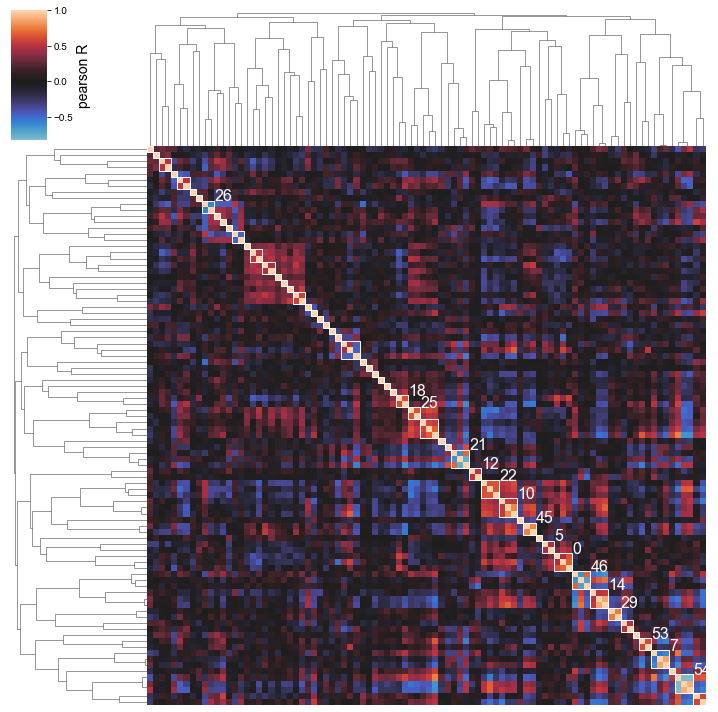

[AgglomerativeClustering(affinity='precomputed', compute_full_tree=True,
                         distance_threshold=0.55, linkage='complete',
                         n_clusters=None)]

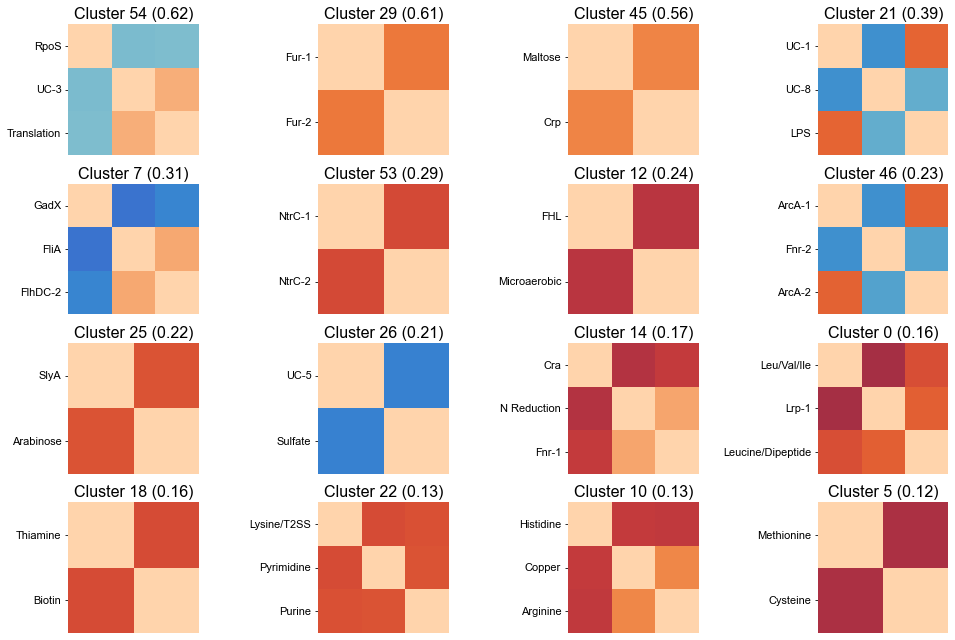

In [6]:
cluster_activities_no_sg(ica_data, show_best_clusters=True, correlation_method='pearson', distance_threshold = 0.55)

## Figure 3A
cluster #54 obtained from code above

In [7]:
def compare_gene_weights(
    ica_data,
    imodulon1,
    imodulon2,
    ica_data2=None,
    ortho_file=None,
    use_org1_names=True,
    **kwargs,
):
    """
    Create a scatterplot comparing the gene weights between two iModulons

    Parameters
    ----------
    ica_data: ~pymodulon.core.IcaData
        :class:`~pymodulon.core.IcaData` object
    imodulon1 : int or str
        Name of `iModulon` on X-axis
    imodulon2 : int or str
        Name of `iModulon` on X-axis
    ica_data2: ~pymodulon.core.IcaData, optional
        :class:`~pymodulon.core.IcaData` object for second iModulon (if comparing
        iModulons across objects)
    ortho_file: str, optional
        Path to orthology file between organisms
    use_org1_names: bool
        If true, use gene names from first organism. If false, use gene names
        from second organism (default: True)
    **kwargs:
        Additional keyword arguments passed to :func:`pymodulon.plotting.scatterplot`

    Returns
    -------
    ax: ~matplotlib.axes.Axes
        :class:`~matplotlib.axes.Axes` containing the scatterplot
    """
    if ica_data2 is None:
        ica_data2 = ica_data.copy()

    M1, M2 = convert_gene_index(ica_data.M, ica_data2.M, ortho_file)
    bin_M1, bin_M2 = convert_gene_index(
        ica_data.M_binarized, ica_data2.M_binarized, ortho_file
    )

    # Convert gene table
    gene_table1, gene_table2 = convert_gene_index(
        ica_data.gene_table, ica_data2.gene_table, ortho_file, keep_locus=True
    )

    if use_org1_names:
        gene_table = gene_table1
        gene_table["locus_tag"] = gene_table.index
    else:
        gene_table = gene_table2

    x = M1[imodulon1]
    y = M2[imodulon2]

    xlabel = f"{imodulon1} Gene Weight"
    ylabel = f"{imodulon2} Gene Weight"

    # Override specific kwargs (their implementation is different
    # in this function)
    show_labels_cgw = kwargs.pop("show_labels", "auto")
    adjust_labels_cgw = kwargs.pop("adjust_labels", True)
    legend_cgw = kwargs.pop("legend", False)
    legend_kwargs_cgw = kwargs.pop("legend_kwargs", {})
    label_font_kwargs_cgw = kwargs.pop("label_font_kwargs", {})

    kwargs["show_labels"] = kwargs["adjust_labels"] = kwargs["legend"] = False
    kwargs["legend_kwargs"] = None

    # Remove xlabel and ylabel kwargs if provided
    kwargs.pop("xlabel", None)
    kwargs.pop("ylabel", None)

    # Scatter Plot
    ax = scatterplot(x, y, xlabel=xlabel, ylabel=ylabel, **kwargs)

    # Add thresholds to scatterplot (dashed lines)
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    thresh1 = ica_data.thresholds[imodulon1]
    thresh2 = ica_data2.thresholds[imodulon2]

    if thresh1 != 0:
        ax.vlines(
            [thresh1, -thresh1],
            ymin=ymin,
            ymax=ymax,
            colors="k",
            linestyles="dashed",
            linewidth=1,
        )

    if thresh2 != 0:
        ax.hlines(
            [thresh2, -thresh2],
            xmin=xmin,
            xmax=xmax,
            colors="k",
            linestyles="dashed",
            linewidth=1,
        )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Add labels on data-points
    component_genes_x = bin_M1[bin_M1[imodulon1] == 1].index
    component_genes_y = bin_M2[bin_M2[imodulon2] == 1].index
    
    # Identify unique genes for each imodulon
    unique_genes_x = bin_M1[bin_M1[imodulon1] == 1].index.difference(bin_M2[bin_M2[imodulon2] == 1].index)
    unique_genes_y = bin_M2[bin_M2[imodulon2] == 1].index.difference(bin_M1[bin_M1[imodulon1] == 1].index)
    
    # Plot the genes unique to imodulon1 (as blue)
    for gene in unique_genes_x:
        ax.scatter(M1.loc[gene, imodulon1], M2.loc[gene, imodulon2], color="pink")
        
    # Plot the genes unique to imodulon2 (as green)
    for gene in unique_genes_y:
        ax.scatter(M1.loc[gene, imodulon1], M2.loc[gene, imodulon2], color="pink")
    
    component_genes = component_genes_x.intersection(component_genes_y)
    texts = []
    expand_kwargs = {"expand_objects": (1.2, 1.4), "expand_points": (1.3, 1.3)}

    # Add labels: Put gene name if components contain under 20 genes
    auto = None
    if show_labels_cgw == "auto":
        auto = (
            bin_M1[imodulon1].astype(bool) & bin_M2[imodulon2].astype(bool)
        ).sum() <= 20

    if show_labels_cgw or auto:
        for gene in component_genes:
            ax.scatter(M1.loc[gene, imodulon1], M2.loc[gene, imodulon2], color="red")

            # Add labels
            text_kwargs = label_font_kwargs_cgw.copy()

            if "fontstyle" not in text_kwargs:
                text_kwargs.update({"fontstyle": "normal"})

            # Italicize gene if there is a defined name (not locus tag)
            try:
                gene_name = gene_table.loc[gene, "gene_name"]
                if gene_name != gene_table.loc[gene, "locus_tag"]:
                    text_kwargs.update({"fontstyle": "italic"})

            except KeyError:
                gene_name = gene

            # Set default fontsize
            if "fontsize" not in text_kwargs:
                text_kwargs.update({"fontsize": 12})

            texts.append(
                ax.text(
                    M1.loc[gene, imodulon1],
                    M2.loc[gene, imodulon2],
                    gene_name,
                    **text_kwargs,
                )
            )

        expand_kwargs["expand_text"] = (1.4, 1.4)

    # Add labels: Repel texts from other text and points
    rectx = ax.add_patch(
        Rectangle(
            xy=(xmin, -abs(thresh2)),
            width=xmax - xmin,
            height=2 * abs(thresh2),
            fill=False,
            linewidth=0,
        )
    )

    recty = ax.add_patch(
        Rectangle(
            xy=(-abs(thresh1), ymin),
            width=2 * abs(thresh1),
            height=ymax - ymin,
            fill=False,
            linewidth=0,
        )
    )

    if adjust_labels_cgw:
        adjust_text(
            texts=texts,
            add_objects=[rectx, recty],
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="k", lw=0.5),
            only_move={"objects": "y"},
            **expand_kwargs,
        )

    # Add legend
    if legend_cgw:
        ax.legend(**legend_kwargs_cgw)

    return ax

<AxesSubplot: xlabel='UC-3 iModulon Activity', ylabel='RpoS iModulon Activity'>

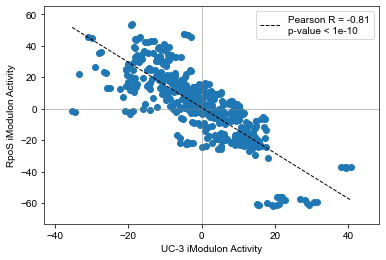

In [8]:
compare_activities(ica_data, 'UC-3', 'RpoS')

<AxesSubplot: xlabel='Translation iModulon Activity', ylabel='RpoS iModulon Activity'>

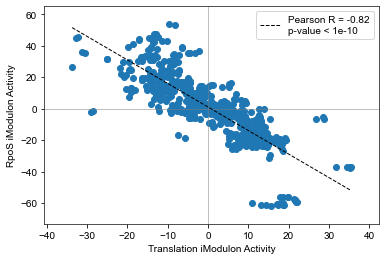

In [9]:
compare_activities(ica_data,'Translation','RpoS')

<AxesSubplot: xlabel='Translation iModulon Activity', ylabel='UC-3 iModulon Activity'>

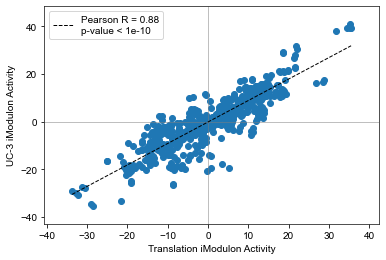

In [10]:
compare_activities(ica_data, 'Translation', 'UC-3')

<AxesSubplot: xlabel='RpoS Gene Weight', ylabel='Translation Gene Weight'>

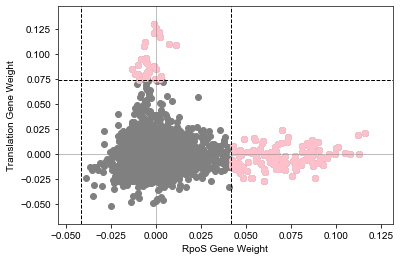

In [11]:
compare_gene_weights(ica_data, 'RpoS','Translation',colors = ['grey'])

<AxesSubplot: xlabel='RpoS Gene Weight', ylabel='UC-3 Gene Weight'>

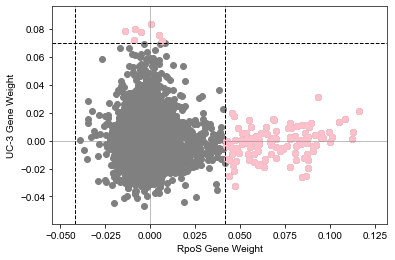

In [12]:
compare_gene_weights(ica_data, 'RpoS','UC-3',colors = ['grey'])

<AxesSubplot: xlabel='UC-3 Gene Weight', ylabel='Translation Gene Weight'>

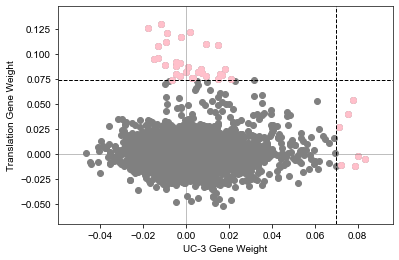

In [13]:
compare_gene_weights(ica_data, 'UC-3', 'Translation',colors = ['grey'])

## Figure 3B

In [14]:
# select samples in regions of interest in the phase plane
samps_of_interest = []
samp_dict = {}

for samp in ica_data.sample_table.index:
    if ica_data.A.loc['RpoS', samp] > 50:
        if ica_data.A.loc['Translation', samp] < 0:
            samps_of_interest.append(samp)
            samp_dict[samp] = ica_data.sample_table.loc[samp, 'condition']

display(samp_dict)
ica_data.sample_table.loc[samps_of_interest]

{'pmg_wt_87': 'L-Asparagine_NH4Cl', 'pmg_wt_88': 'L-Asparagine_NH4Cl'}

,sample_id,study,project,reference_condition,reference_condition_old,condition,rep_id,Strain Description,Strain,Culture Type,Evolved Sample,Base Media,Temperature (C),pH,Carbon Source (g/L),Nitrogen Source (g/L),Electron Acceptor,Trace Element Mixture,Supplement,Antibiotic for selection,Growth_Phase,Growth Rate (1/hr),Isolate Type,Additional Details,Sequencing Machine,LibraryLayout,Platform,Biological Replicates,doi,GEO,SRX,Run,R1,R2,contact,creator,passed_fastqc,passed_pct_reads_mapped,passed_reads_mapped_to_CDS,passed_global_correlation,full_name,passed_similar_replicates,passed_number_replicates,run_date,n_replicates,PxK_sample_type,deleted_genes,mutated_genes,overexpressed_genes,passed_replicate_correlations,show_study,study_sort,qc_id
pmg_wt_87,C_L-Asparagine_1,single_nutrient_perturbation,SNPv1,pmg_wt_77;pmg_wt_78,D-Glucose_NH4Cl,L-Asparagine_NH4Cl,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,M9,37,7.0,L-Asparagine(5),NH4Cl(1),O2,Sauer trace element mixture,NaN,NaN,NaN,0.13,NaN,NaN,AVITI,PAIRED,Element Biosciences,2,NaN,PRJNA1273304,NaN,NaN,s3://sbrg-sequencing-files/2024-04-23-SBP-AVIT...,s3://sbrg-sequencing-files/2024-04-23-SBP-AVIT...,Jongoh Shin,Jaemin Sung,True,NaN,True,True,SNPv1:L-Asparagine_NH4Cl,NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,True,single_nutrient_perturbation,0,pxk_0200
pmg_wt_88,C_L-Asparagine_2,single_nutrient_perturbation,SNPv1,pmg_wt_77;pmg_wt_78,D-Glucose_NH4Cl,L-Asparagine_NH4Cl,2,Escherichia coli K-12 MG1655,MG1655,Batch,No,M9,37,7.0,L-Asparagine(5),NH4Cl(1),O2,Sauer trace element mixture,NaN,NaN,NaN,0.13,NaN,NaN,AVITI,PAIRED,Element Biosciences,2,NaN,PRJNA1273304,NaN,NaN,s3://sbrg-sequencing-files/2024-04-23-SBP-AVIT...,s3://sbrg-sequencing-files/2024-04-23-SBP-AVIT...,Jongoh Shin,Jaemin Sung,True,NaN,True,True,SNPv1:L-Asparagine_NH4Cl,NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,True,single_nutrient_perturbation,0,pxk_0201


In [15]:
# translation and UC-3; translation and RpoS --  selected conditions to highlight
# 
groups = {'pmg_wt_13': 'anaerobic conditions',
 'pmg_wt_14': 'anaerobic conditions',
 'pmg_wt_492': 'anaerobic conditions',
 'pmg_wt_493': 'anaerobic conditions',
 'pmg_wt_508': 'anaerobic conditions',
 'pmg_wt_509': 'anaerobic conditions',
 'pmg_wt_568': 'wt_ph5',
 'pmg_wt_569': 'wt_ph5',
 'pmg_wt_570': 'wt_ph8',
 'pmg_wt_571': 'wt_ph8',
 'pmg_wt_466': 'ebk_dmso10_biod',
 'pmg_wt_467': 'ebk_dmso10_biod',
 'pmg_wt_468': 'ebk_hnq10_biod',
 'pmg_wt_469': 'ebk_hnq10_biod',
 'pmg_wt_470': 'ebk_hnq10_biod',
 'pmg_wt_471': 'ebk_hnq2_biod',
 'pmg_wt_472': 'ebk_hnq2_biod',
 'pmg_wt_473': 'ebk_hnq2_biod',
 'pmg_wt_17': 'paraquat',
 'pmg_wt_18': 'paraquat',
 'pmg_wt_484': 'cytd_rib',
 'pmg_wt_485': 'cytd_rib',
 'pmg_wt_552': 'wt_etoh',
 'pmg_wt_553': 'wt_etoh', 
 'pmg_wt_369': 'stationary (> 4h)',
 'pmg_wt_370': 'stationary (> 4h)',
 'pmg_wt_359': 'stationary (> 4h)',
 'pmg_wt_360': 'stationary (> 4h)',
 'pmg_wt_361': 'stationary (> 4h)',
 'pmg_wt_362': 'stationary (> 4h)',
 'pmg_wt_363': 'stationary (> 4h)',
 'pmg_wt_364': 'stationary (> 4h)',
 'pmg_wt_365': 'stationary (> 4h)',
 'pmg_wt_366': 'stationary (> 4h)',
 'pmg_wt_367': 'stationary (> 4h)',
 'pmg_wt_368': 'stationary (> 4h)',
 'pmg_wt_371': 'abx_media_project: m9',
 'pmg_wt_372': 'abx_media_project: m9',
 'pmg_wt_373': 'abx_media_project: rpmi',
 'pmg_wt_374': 'abx_media_project: rpmi',
 'pmg_wt_375': 'abx_media_project: camhb',
 'pmg_wt_376': 'abx_media_project: camhb',
 'pmg_wt_377': 'abx_media_project: m9',
 'pmg_wt_378': 'abx_media_project: m9',
 'pmg_wt_379': 'abx_media_project: rpmi',
 'pmg_wt_380': 'abx_media_project: rpmi',
 'pmg_wt_381': 'abx_media_project: camhb',
 'pmg_wt_382': 'abx_media_project: camhb',
 'pmg_wt_383': 'abx_media_project: m9',
 'pmg_wt_384': 'abx_media_project: m9',
 'pmg_wt_385': 'abx_media_project: rpmi',
 'pmg_wt_386': 'abx_media_project: rpmi',
 'pmg_wt_387': 'abx_media_project: camhb',
 'pmg_wt_388': 'abx_media_project: camhb',
 'pmg_wt_389': 'abx_media_project: m9',
 'pmg_wt_390': 'abx_media_project: m9',
 'pmg_wt_391': 'abx_media_project: rpmi',
 'pmg_wt_392': 'abx_media_project: rpmi',
 'pmg_wt_393': 'abx_media_project: camhb',
 'pmg_wt_394': 'abx_media_project: camhb',
 'pmg_wt_395': 'abx_media_project: m9',
 'pmg_wt_396': 'abx_media_project: m9',
 'pmg_wt_397': 'abx_media_project: rpmi',
 'pmg_wt_398': 'abx_media_project: rpmi',
 'pmg_wt_399': 'abx_media_project: camhb',
 'pmg_wt_400': 'abx_media_project: camhb',
 'pmg_wt_87': 'L-Asparagine_NH4Cl',
 'pmg_wt_88': 'L-Asparagine_NH4Cl',
 'pmg_wt_550': 'wt_CuSO4',
 'pmg_wt_551': 'wt_CuSO4'}

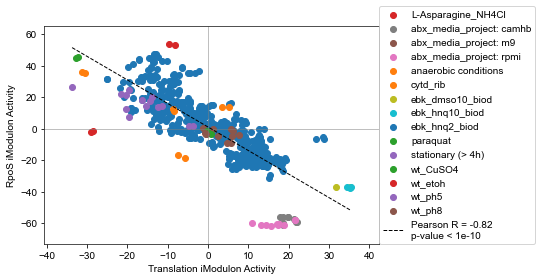

In [16]:
ax = compare_activities(ica_data, 'Translation', 'RpoS', groups = groups)
ax.legend(loc = (1,0))

## Figure 3C

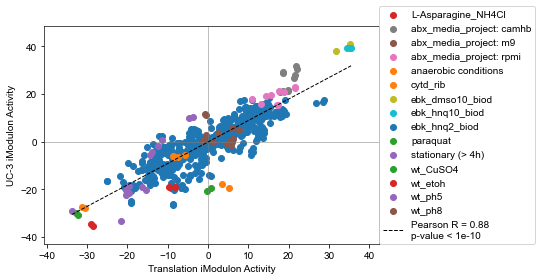

In [17]:
ax = compare_activities(ica_data, 'Translation', 'UC-3', groups = groups)
ax.legend(loc = (1,0))

## Figure 3D
cluster #46 obtained from code above

<AxesSubplot: xlabel='Fnr-2 iModulon Activity', ylabel='ArcA-1 iModulon Activity'>

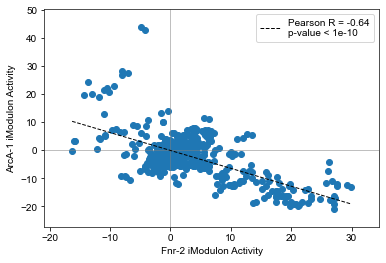

In [18]:
compare_activities(ica_data, 'Fnr-2', 'ArcA-1')

<AxesSubplot: xlabel='ArcA-2 iModulon Activity', ylabel='ArcA-1 iModulon Activity'>

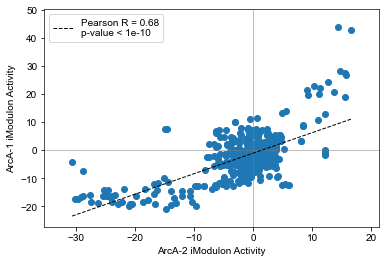

In [19]:
compare_activities(ica_data,'ArcA-2', 'ArcA-1')

<AxesSubplot: xlabel='ArcA-2 iModulon Activity', ylabel='Fnr-2 iModulon Activity'>

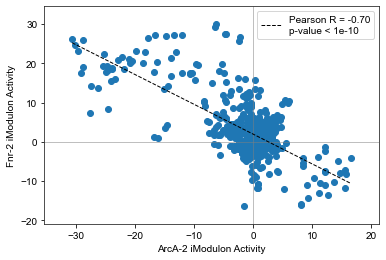

In [20]:
compare_activities(ica_data,'ArcA-2', 'Fnr-2')

<AxesSubplot: xlabel='ArcA-1 Gene Weight', ylabel='ArcA-2 Gene Weight'>

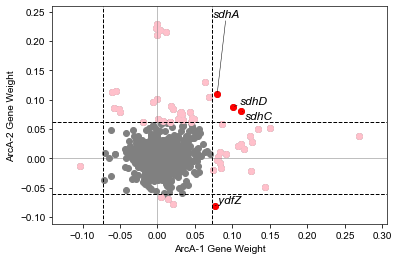

In [21]:
compare_gene_weights(ica_data, 'ArcA-1', 'ArcA-2',colors = ['grey'])

<AxesSubplot: xlabel='ArcA-1 Gene Weight', ylabel='Fnr-2 Gene Weight'>

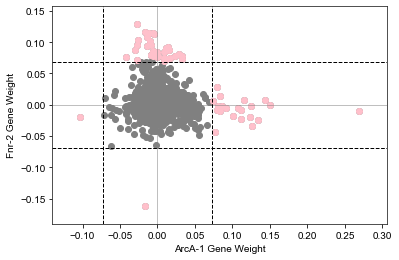

In [22]:
compare_gene_weights(ica_data, 'ArcA-1', 'Fnr-2',colors = ['grey'])

<AxesSubplot: xlabel='Fnr-2 Gene Weight', ylabel='ArcA-2 Gene Weight'>

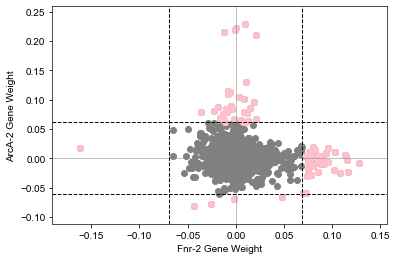

In [23]:
compare_gene_weights(ica_data, 'Fnr-2', 'ArcA-2', colors = ['grey'])

## Figure 3E

<AxesSubplot: xlabel='ArcA-2 Gene Weight', ylabel='ArcA-1 Gene Weight'>

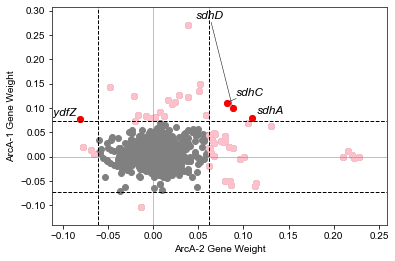

In [24]:
compare_gene_weights(ica_data, 'ArcA-2', 'ArcA-1',colors = ['grey'])

## Figure 3F

In [25]:
# ArcA-1 and ArcA-2 -- samples to highlight in phase plane
groups = {'pmg_wt_369': 'stationary (> 4h)',
 'pmg_wt_370': 'stationary (> 4h)',
 'pmg_wt_359': 'stationary (> 4h)',
 'pmg_wt_360': 'stationary (> 4h)',
 'pmg_wt_361': 'stationary (> 4h)',
 'pmg_wt_362': 'stationary (> 4h)',
 'pmg_wt_363': 'stationary (> 4h)',
 'pmg_wt_364': 'stationary (> 4h)',
 'pmg_wt_365': 'stationary (> 4h)',
 'pmg_wt_366': 'stationary (> 4h)',
 'pmg_wt_367': 'stationary (> 4h)',
 'pmg_wt_368': 'stationary (> 4h)',
 'pmg_wt_550': 'wt_CuSO4',
 'pmg_wt_551': 'wt_CuSO4',
 'pmg_wt_564': 'wt_zncl2',
 'pmg_wt_565': 'wt_zncl2',
 'pmg_wt_556': 'wt_LiAcet',
 'pmg_wt_557': 'wt_LiAcet',
 'pmg_wt_558': 'wt_LiCl',
 'pmg_wt_559': 'wt_LiCl',
 'pmg_wt_221': 'Supp_Cysteine_(10mM)',
 'pmg_wt_222': 'Supp_Cysteine_(10mM)',
 'pmg_wt_13': 'anaerobic conditions',
 'pmg_wt_14': 'anaerobic conditions',
 'pmg_wt_267': 'Supp_2-Deoxyadenosine_(10mM)',
 'pmg_wt_268': 'Supp_2-Deoxyadenosine_(10mM)',
 'pmg_wt_305': 'Supp_D-Glucose-6-Phosphate_(2mM)',
 'pmg_wt_306': 'Supp_D-Glucose-6-Phosphate_(2mM)',
 'pmg_wt_493': 'anaerobic conditions',
 'pmg_wt_508': 'anaerobic conditions',
 'pmg_wt_509': 'anaerobic conditions',
 'pmg_wt_17': 'paraquat',
 'pmg_wt_18': 'paraquat'}

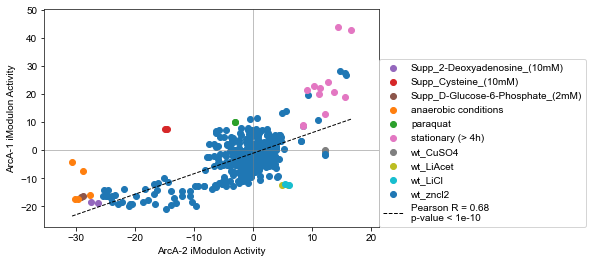

In [26]:
ax = compare_activities(ica_data, 'ArcA-2', 'ArcA-1', groups = groups)
ax.legend(loc = (1,0))